## Naive Approach - Distributional Shift with a SMW
In the Naive Approach the distributional Shift comes from mutating random positions in a sequence with a Single Mutant Walker. The sequences are scored by a surrogate model where the best found sequence is added to the trajectroy and used as the next seed sequence for further mutation.


#### SMW and Random Forest on TFBind8

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from experiment_loop import run_multiple_experiments
from assets.plot import plot_trajectories
from models.random_forest import RandomForestModel

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:


test_sets = ["test_a", "test_b", "test_c"]
runs = 10
num_rounds = 20
mutants_per_round = 50

rf = RandomForestModel(n_estimators=200, random_state=42)

all_trajectories = run_multiple_experiments(model=rf, seed=42, test_sets=test_sets, runs=runs, change_seed_sequence=True, num_rounds=num_rounds, mutants_per_round=mutants_per_round, return_stats=True)
trajectories_rf = pd.concat(all_trajectories, ignore_index=True) if all_trajectories else pd.DataFrame()



Running experiment for test_a...
Run 1/10 for test_a...
Selected seed sequence: GGCTGGGC with oracle score: 0.31944501399993896
Stats: generated=1000 in_target=1 improvements=0 wrong_split=18 seen=981
Run 2/10 for test_a...
Selected seed sequence: CTTGAACT with oracle score: 0.40957820415496826
Stats: generated=1000 in_target=14 improvements=1 wrong_split=20 seen=966
Run 3/10 for test_a...
Selected seed sequence: GTTCAAGA with oracle score: 0.31246650218963623
Stats: generated=1000 in_target=53 improvements=8 wrong_split=49 seen=898
Run 4/10 for test_a...
Selected seed sequence: GGCACAAA with oracle score: 0.3876015245914459
Stats: generated=1000 in_target=7 improvements=1 wrong_split=25 seen=968
Run 5/10 for test_a...
Selected seed sequence: TGAAGGAC with oracle score: 0.37521132826805115
Stats: generated=1000 in_target=0 improvements=0 wrong_split=18 seen=982
Run 6/10 for test_a...
Selected seed sequence: GGCCAAGC with oracle score: 0.35565704107284546
Stats: generated=1000 in_targe

In [7]:
display(
    trajectories_rf.sort_values(["evaluated_split", "run", "round"])[
        ["evaluated_split", "run", "round", "sequence", "surrogate_score", "oracle_score"]
    ]
)

,evaluated_split,run,round,sequence,surrogate_score,oracle_score
0,test_a,1,0,GGCTGGGC,0.294815,0.319445
1,test_a,2,0,CTTGAACT,0.378999,0.409578
2,test_a,2,1,CTTAAACT,0.402877,0.368027
3,test_a,3,0,GTTCAAGA,0.307759,0.312467
4,test_a,3,1,GTTCAATA,0.338476,0.604544
...,...,...,...,...,...,...
103,test_c,9,3,TTGAAATC,0.390653,0.370449
104,test_c,9,4,TCGAAATC,0.393607,0.235754
105,test_c,9,5,TCTAAATC,0.397128,0.635808
106,test_c,9,6,TCTATATC,0.398143,0.924607


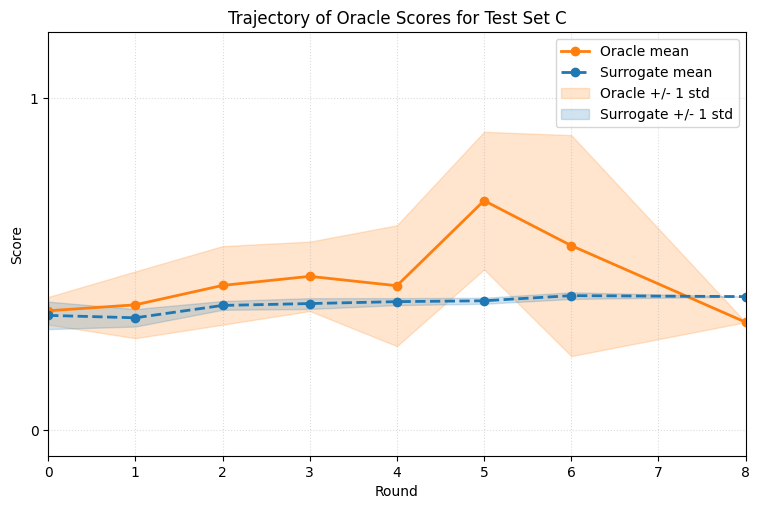

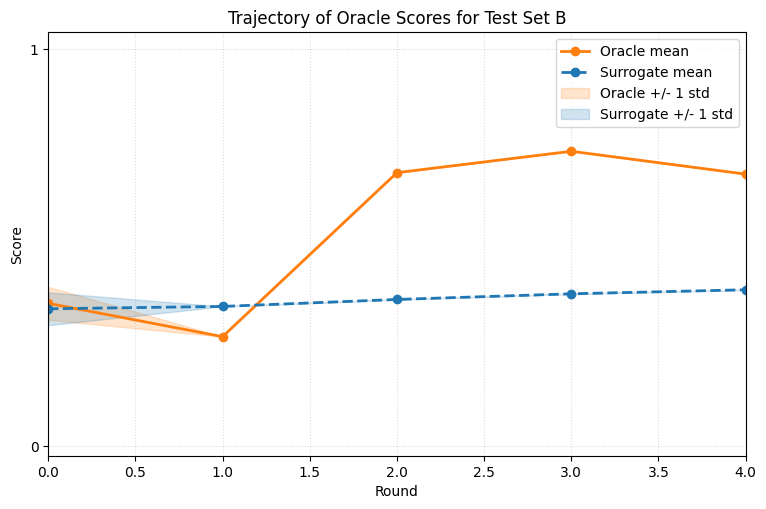

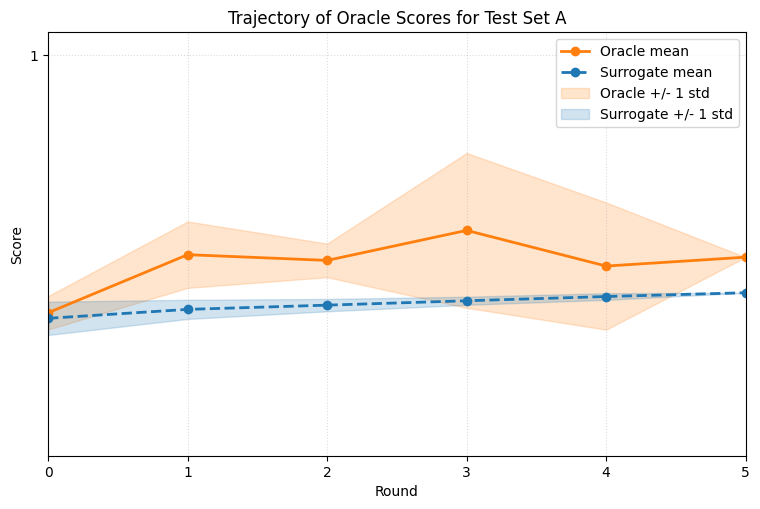

In [8]:
ax_1 = plot_trajectories(trajectories_rf, test_set="test_c")
ax_1.set_title("Trajectory of Oracle Scores for Test Set C")
ax_2 = plot_trajectories(trajectories_rf, test_set="test_b")
ax_2.set_title("Trajectory of Oracle Scores for Test Set B")
ax_3 = plot_trajectories(trajectories_rf, test_set="test_a")
ax_3.set_title("Trajectory of Oracle Scores for Test Set A")
plt.show()

#### SMW with MLP


In [5]:
from models import mlp

mlp = mlp.MLPModel()

trajectories_mlp = run_multiple_experiments(test_sets, runs, surrogate_model=mlp, change_seed_sequence=True)
trajectories_mlp = pd.concat(trajectories_mlp, ignore_index=True) if trajectories_mlp else pd.DataFrame()

TypeError: run_multiple_experiments() got an unexpected keyword argument 'surrogate_model'

In [ ]:
ax_1 = plot_trajectories(trajectories_mlp, test_set="test_c")
ax_1.set_title("Trajectory of Oracle Scores for Test Set C")
ax_2 = plot_trajectories(trajectories_mlp, test_set="test_b")
ax_2.set_title("Trajectory of Oracle Scores for Test Set B")
ax_3 = plot_trajectories(trajectories_mlp, test_set="test_a")
ax_3.set_title("Trajectory of Oracle Scores for Test Set A")
plt.show()